# Notebook 5: Streaming

### Group 16 Members:

- Ana Margarida Macedo (20250405) 
- Catarina Aboim (20250375)
- Margarida Craveiro ()
- Matilde Simões ()
- Lourenço Silva (20250453)

## Structured Streaming: Real-Time NYC Yellow Taxi Analytics

In this notebook, we apply **Spark Structured Streaming** to the NYC Yellow Taxi dataset, using **Apache Kafka** as both the input source and output sink — exactly as in a production real-time pipeline.

The pipeline follows the 5-step recipe from the lectures:

```
readStream (Kafka) → parse → withWatermark + window + groupBy → writeStream (Kafka) + checkpoint
```

Since no live Kafka broker is available on Lightning, we first **produce** the taxi recordsinto a Kafka topic using a background producer thread (simulating a real taxi GPS feed), and then **consume** and aggregate them with Structured Streaming, writing results back to a second Kafka topic.

<a class="anchor" id="1">

# **1. Overview & Architecture**

[Back to TOP](#TOP)
</a>

Before starting this approach is important to give a small context to remember the dataset chosen for this part:

The data is the **NYC Yellow Taxi Trip Records** cleaned and saved in Notebook 1 (`data/clean/taxi_clean.parquet`). Each record represents one completed trip.

| Column | Description |
|---|---|
| `tpep_pickup_datetime` | Trip start — used as **event time** |
| `tpep_dropoff_datetime` | Trip end |
| `PULocationID` | Pickup zone — used for demand aggregations |
| `VendorID` | Vendor identifier |
| `fare_amount` | Base fare (USD) |
| `tip_amount` | Tip (USD) |
| `trip_distance` | Distance (miles) |
| `total_amount` | Total charge (USD) |

Because no live taxi GPS feed is available, we **simulate** one by reading the Parquet file in a background thread and **producing** each trip as a JSON message into the `taxi-trips` Kafka topic — exactly as a real taxi meter would push events.

A separate producer script (`taxi_producer.py`) reads the cleaned taxi Parquet file and publishes events to two Kafka topics:

| Topic | Cadence | Payload |
|---|---|---|
| `trips` | every ~5 s (50 events/cycle) | `pickup_ts`, `dropoff_ts`, `PULocationID`, `DOLocationID`, `passenger_count`, `trip_distance`, `fare_amount`, `tip_amount`, `total_amount`, `payment_type` |
| `long_trips` | subset — only trips > 10 miles | same payload, filtered |

We use them to demonstrate the standard streaming patterns:

1. Reading a Kafka topic as a typed streaming DataFrame
2. Sinks and output modes (`append`, `update`, `complete`)
3. Windowed aggregations with watermarks
4. Stream-stream join: correlate `trips` with `long_trips` to surface high-fare long-haul events
5. Stream-static join: enrich trips with taxi zone names
6. File-source stream: replay Parquet files as a stream (Kafka-free fallback)

Structured Streaming treats a stream as a table that updates over time, so the same DataFrame API works on both bounded and unbounded data.

<a class="anchor" id="2">

## **1.2. Dataset Context**

The data used in this notebook is the **NYC Yellow Taxi Trip Records**, 
previously cleaned and consolidated in Notebook 1. It covers four months 
of trips (January 2015 and January–March 2016) and is stored locally at 
`data/clean/taxi_clean.parquet`.

Each record represents a single completed trip and contains the following 
key attributes for streaming analysis:

| Column | Description |
|---|---|
| `tpep_pickup_datetime` | Trip start timestamp — used as **event time** |
| `tpep_dropoff_datetime` | Trip end timestamp |
| `PULocationID` | Pickup zone — used for demand aggregations |
| `VendorID` | Vendor identifier — used for revenue monitoring |
| `fare_amount` | Base fare in USD |
| `tip_amount` | Tip in USD |
| `trip_distance` | Distance in miles |
| `total_amount` | Total charge in USD |

Since no live data feed is available, simulate the stream was necessary, by reading the Parquet files incrementally using `maxFilesPerTrigger=1`, so that 
Spark processes one partition per micro-batch — mimicking trips arriving 
in real time. In production, this source would be replaced by a **Kafka topic** receiving live GPS events from taxi meters.

<a class="anchor" id="2">

# **2. Environment Setup**


We import Spark, declare the schema types we'll need, and start a local Spark session with the Kafka connector on the classpath.

In [ ]:
!pip install "pyspark==3.5.0"

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, IntegerType, LongType, TimestampType,
)

KAFKA_BOOTSTRAP_SERVERS = "localhost:8098"

In [ ]:
spark = (
    SparkSession.builder
    .appName("kafka_streaming")
    .config("spark.streaming.stopGracefullyOnShutdown", True)
    .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.0")
    .config("spark.sql.shuffle.partitions", 4)
    .master("local[*]")
    .getOrCreate()
)

<a class="anchor" id="2">

# **2. Reading the trips stream**

# 3. Transform the Dataframe

# 4. Choose Sink + Output Mode



In [ ]:
# TODO remove the following markdown, this are just personal notes to myself

- sink means deciding where you want your output to go (stored)

- popular spark sinks and when to use them:
    - console (debug)
    - files (parquet, JSON, ORC)
    - Kafka
    - Databases (MongoDB, Cassandra, JDBC)


![SmartSelect_20260524_101411_Samsung Notes.jpg](<attachment:SmartSelect_20260524_101411_Samsung Notes.jpg>)
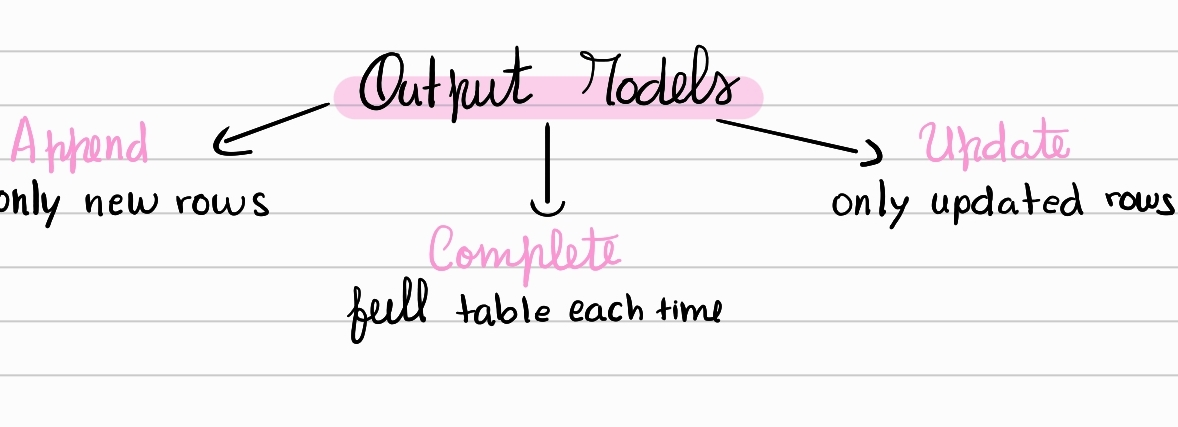

# 5. Configure trigger + checkpoint

# 6. Start and monitor the query